# Model training and MLflow tracking

This notebook trains baseline models for credit scoring and tracks experiments with MLflow.

In [25]:
import os
import sys
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import mlflow
import mlflow.sklearn

from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.dummy import DummyClassifier

import lightgbm as lgb
from lightgbm import LGBMClassifier

sys.path.append(os.path.abspath(".."))

# 1. Chargement des données

In [ ]:
# chargement des données prétaitées
train_df = pd.read_csv("../data/processed/train_processed.csv")

print(train_df.shape)

(10000, 312)


## 1.1 découpage X, y

In [4]:
# X, y 
features = [
    col for col in train_df.columns
    if col not in ["TARGET", "SK_ID_CURR", "SK_ID_BUREAU", "SK_ID_PREV", "index"]
]

X = train_df[features]
y = train_df["TARGET"]

print("Shape X :", X.shape)
print("Shape y :", y.shape)
print("Répartition de TARGET :")
print(y.value_counts(normalize=True))

Shape X : (10000, 310)
Shape y : (10000,)
Répartition de TARGET :
TARGET
0    0.9225
1    0.0775
Name: proportion, dtype: float64


In [13]:
# =========================
# Nettoyage des noms de colonnes
# =========================

import re

# Remplacement des caractères spéciaux par "_"
X.columns = [
    re.sub(r'[^A-Za-z0-9_]+', '_', col)
    for col in X.columns
]

# Vérification
X.columns[:10]

Index(['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED'],
      dtype='object')

# 2. Modélisation
## 2.1. Modèle dummy

In [29]:
with mlflow.start_run(run_name="dummy_baseline"):

    # Tags MLflow
    mlflow.set_tags({
        "project": "home_credit",
        "model_type": "Dummy classifier",
        "author": "Faiza",
        "validation": "-"
    })

    dummy = DummyClassifier(strategy="prior", random_state=42)

    dummy.fit(X, y)

    dummy_preds = dummy.predict_proba(X)[:, 1]

    dummy_auc = roc_auc_score(y, dummy_preds)

    mlflow.log_param("model_type", "DummyClassifier")
    mlflow.log_param("strategy", "prior")
    mlflow.log_metric("roc_auc", dummy_auc)

    mlflow.sklearn.log_model(dummy, name="dummy_baseline_model")

    print("Dummy AUC:", dummy_auc)

2026/05/19 11:16:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/19 11:16:34 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Dummy AUC: 0.5


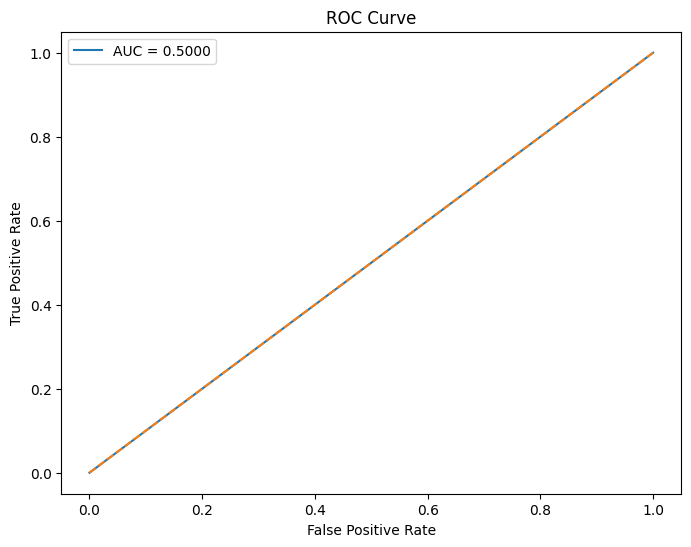

In [28]:
# Calcul courbe ROC
fpr, tpr, thresholds = roc_curve(y, dummy_preds)

# Plot
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {dummy_auc:.4f}")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

## 2.2. Modèle LightGBM 
### Validation croisée stratifiée + tracking MLflow

In [16]:
import mlflow
import os

print("Current directory :", os.getcwd())
print("Tracking URI :", mlflow.get_tracking_uri())

Current directory : c:\Users\fkhellad\Formation_IA\Projet6_mission\notebooks
Tracking URI : sqlite:///C:/Users/fkhellad/Formation_IA/Projet6_mission/notebooks/mlflow.db


In [5]:
# Nombre de folds pour la validation croisée
N_SPLITS = 5
RANDOM_STATE = 42

# Paramètres LightGBM
params = {
    "n_estimators": 1000,
    "learning_rate": 0.03,
    "num_leaves": 34,
    "max_depth": 8,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "objective": "binary",
    "class_weight": "balanced",
    "random_state": RANDOM_STATE,
    "n_jobs": -1
}

In [6]:
# Configuration MLflow
#-------------------------
# Nom de l'expérience visible dans l'interface MLflow
mlflow.set_experiment("home_credit_scoring")

2026/05/18 11:47:31 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/18 11:47:31 INFO mlflow.store.db.utils: Updating database tables
2026/05/18 11:47:33 INFO mlflow.tracking.fluent: Experiment with name 'home_credit_scoring' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///c:/Users/fkhellad/Formation_IA/Projet6_mission/notebooks/mlruns/1', creation_time=1779097653397, experiment_id='1', last_update_time=1779097653397, lifecycle_stage='active', name='home_credit_scoring', tags={}, trace_location=None, workspace='default'>

In [ ]:
# StratifiedKFold garde la même proportion de TARGET=0 et TARGET=1 dans chaque fold
folds = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Stocker les prédictions out-of-fold
# Chaque client reçoit une prédiction venant d'un modèle qui ne l'a pas vu à l'entraînement
oof_preds = np.zeros(len(train_df))

# Stocker l'importance des variables pour chaque fold
feature_importance = pd.DataFrame()

# Stocker le score AUC de chaque fold
fold_scores = []

# Run MLflow principal
with mlflow.start_run(run_name="lightgbm_stratified_kfold"):

     # Tags MLflow
    mlflow.set_tags({
        "project": "home_credit",
        "model_type": "LightGBM",
        "author": "Faiza",
        "validation": "StratifiedKFold"
    })
    
    # enregistrer les paramètres globaux du modèle
    mlflow.log_params(params)
    mlflow.log_param("n_splits", N_SPLITS)
    mlflow.log_param("validation_strategy", "StratifiedKFold")

    # Boucle sur chaque fold
    for fold, (train_idx, valid_idx) in enumerate(folds.split(X, y), start=1):

        print(f"\n===== Fold {fold}/{N_SPLITS} =====")

        # Séparation des données pour le fold courant
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_valid, y_valid = X.iloc[valid_idx], y.iloc[valid_idx]

        # Run MLflow secondaire pour suivre chaque fold séparément
        with mlflow.start_run(run_name=f"fold_{fold}", nested=True):

            # Création du modèle LightGBM
            model = LGBMClassifier(**params)

            # Entraînement du modèle
            model.fit(
                X_train,
                y_train, 

                # Jeu de validation utilisé pour suivre la performance pendant l'entraînement
                eval_set=[(X_valid, y_valid)],

                # Métrique utilisée pendant l'entraînement
                eval_metric="auc",

                # Early stopping :
                # si l'AUC ne s'améliore plus pendant 100 itérations, l'entraînement s'arrête
                callbacks=[
                    lgb.early_stopping(stopping_rounds=100),
                    lgb.log_evaluation(period=100)
                ]
            )

            # Prédiction de la probabilité d'être en défaut TARGET=1
            valid_preds = model.predict_proba(X_valid)[:, 1]

            # placer les prédictions au bon endroit dans le tableau global OOF
            oof_preds[valid_idx] = valid_preds

            # Calcul du ROC-AUC pour ce fold
            fold_auc = roc_auc_score(y_valid, valid_preds)

            # Sauvegarde du score du fold
            fold_scores.append(fold_auc)

            print(f"Fold {fold} AUC: {fold_auc:.5f}")

            # Logging MLflow du fold
            mlflow.log_params(params)
            mlflow.log_param("fold", fold)
            mlflow.log_metric("fold_auc", fold_auc)
            mlflow.log_metric("best_iteration", model.best_iteration_)

            # Importance des variables pour ce fold
            fold_importance = pd.DataFrame({
                "feature": features,
                "importance": model.feature_importances_,
                "fold": fold
            })

            # Ajout des importances au tableau global
            feature_importance = pd.concat(
                [feature_importance, fold_importance],
                axis=0
            )

            # Sauvegarde du modèle du fold dans MLflow
            mlflow.sklearn.log_model(
                sk_model=model,
                name=f"lightgbm_fold_{fold}"
            )

    # Score global sur toutes les prédictions out-of-fold
    full_auc = roc_auc_score(y, oof_preds)

    # Logging des métriques globales
    mlflow.log_metric("mean_fold_auc", np.mean(fold_scores))
    mlflow.log_metric("std_fold_auc", np.std(fold_scores))
    mlflow.log_metric("full_oof_auc", full_auc)

    print("\n==============================")
    print("Mean Fold AUC:", np.mean(fold_scores))
    print("Std Fold AUC :", np.std(fold_scores))
    print("Full OOF AUC :", full_auc)


===== Fold 1/5 =====
[LightGBM] [Info] Number of positive: 620, number of negative: 7380
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008068 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7874
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 310
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.750475	valid_0's binary_logloss: 0.438913
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

2026/05/19 11:16:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/19 11:16:49 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



===== Fold 2/5 =====
[LightGBM] [Info] Number of positive: 620, number of negative: 7380
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007534 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7908
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 310
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.749628	valid_0's binary_logloss: 0.441621
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[200]	valid_0's auc: 0.750772	valid_0's binary_logloss: 0.3752

2026/05/19 11:16:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/19 11:16:59 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



===== Fold 3/5 =====
[LightGBM] [Info] Number of positive: 620, number of negative: 7380
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007370 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7904
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 310
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.76079	valid_0's binary_logloss: 0.423861
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[85]	valid_0's auc: 0.762483	valid_0's binary_logloss: 0.441201
Fold 3 AUC: 0.76248


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[32]	valid_0's auc: 0.743602	valid_0's binary_logloss: 0.545788
Fold 4 AUC: 0.74360


2026/05/19 11:17:14 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



===== Fold 5/5 =====
[LightGBM] [Info] Number of positive: 620, number of negative: 7380
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008032 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7896
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 310
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.729983	valid_0's binary_logloss: 0.437127
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

2026/05/19 11:17:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/19 11:17:22 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Fold AUC: 0.7497602937319695
Std Fold AUC : 0.011097778871894996
Full OOF AUC : 0.7398052976658799


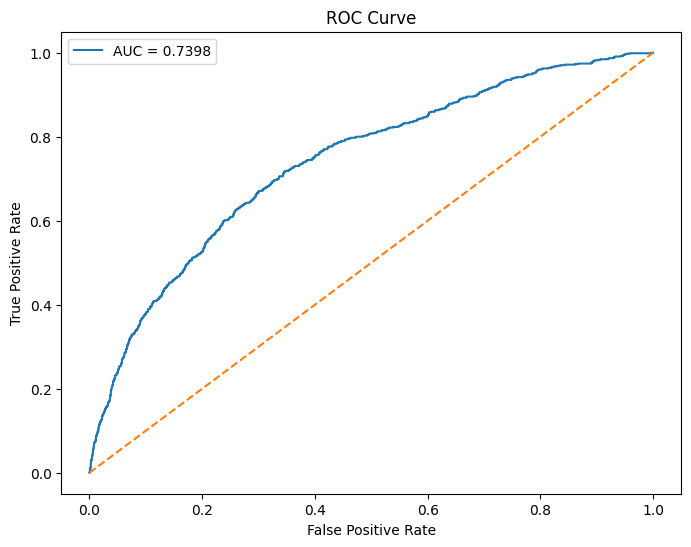

In [19]:
# Calcul courbe ROC
fpr, tpr, thresholds = roc_curve(y, oof_preds)

# Plot
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {full_auc:.4f}")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

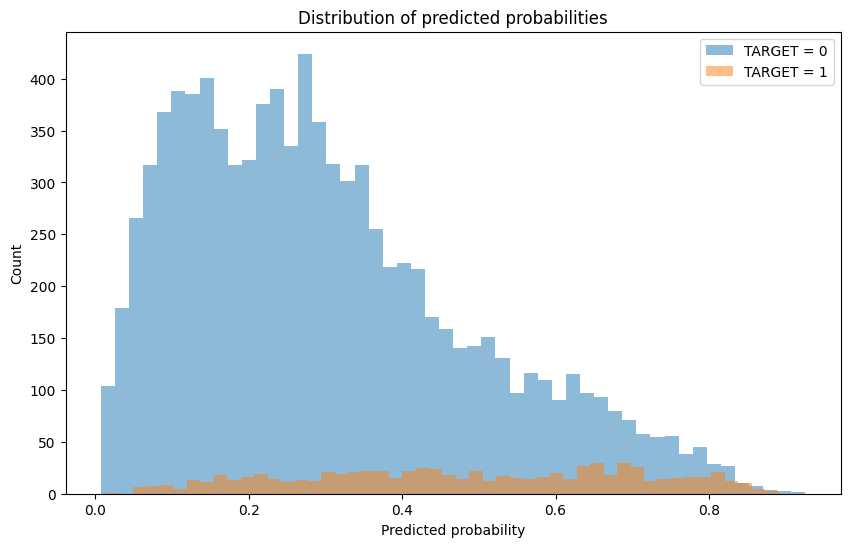

In [20]:
plt.figure(figsize=(10,6))

plt.hist(
    oof_preds[y == 0],
    bins=50,
    alpha=0.5,
    label="TARGET = 0"
)

plt.hist(
    oof_preds[y == 1],
    bins=50,
    alpha=0.5,
    label="TARGET = 1"
)

plt.xlabel("Predicted probability")
plt.ylabel("Count")

plt.title("Distribution of predicted probabilities")

plt.legend()

plt.show()

## 2.3 Feature importance
### SHAP

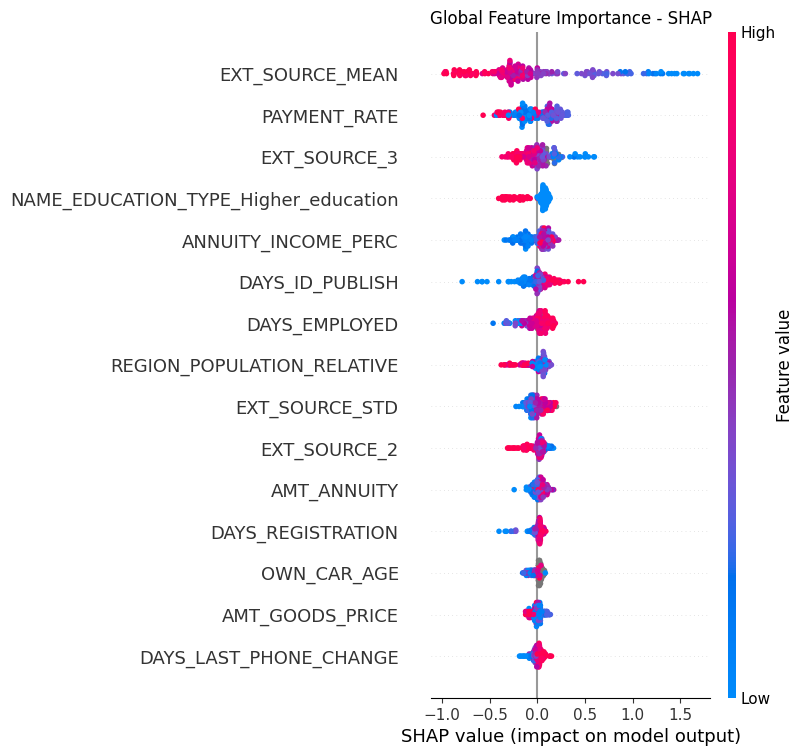

In [47]:
# =========================
# Feature importance avec SHAP
# =========================

import shap

# échantillon pour accélérer SHAP
X_shap = X_valid.sample(
    min(200, len(X_valid)),
    random_state=42
)

# Labels correspondant à X_shap
y_shap = y_valid.loc[X_shap.index]

# explainer spécialisé arbres
explainer = shap.TreeExplainer(model)

# calcul des valeurs SHAP
shap_values = explainer.shap_values(X_shap)

# SHAP crée lui-même la figure
shap.summary_plot(
    shap_values,
    X_shap,
    max_display=15,
    show=False
)

# récupération de la figure courante
fig = plt.gcf()

# ajout du titre
plt.title("Global Feature Importance - SHAP")

# sauvegarde
#plt.savefig("feature_importance_shap.png", dpi=300, bbox_inches="tight")

plt.show()

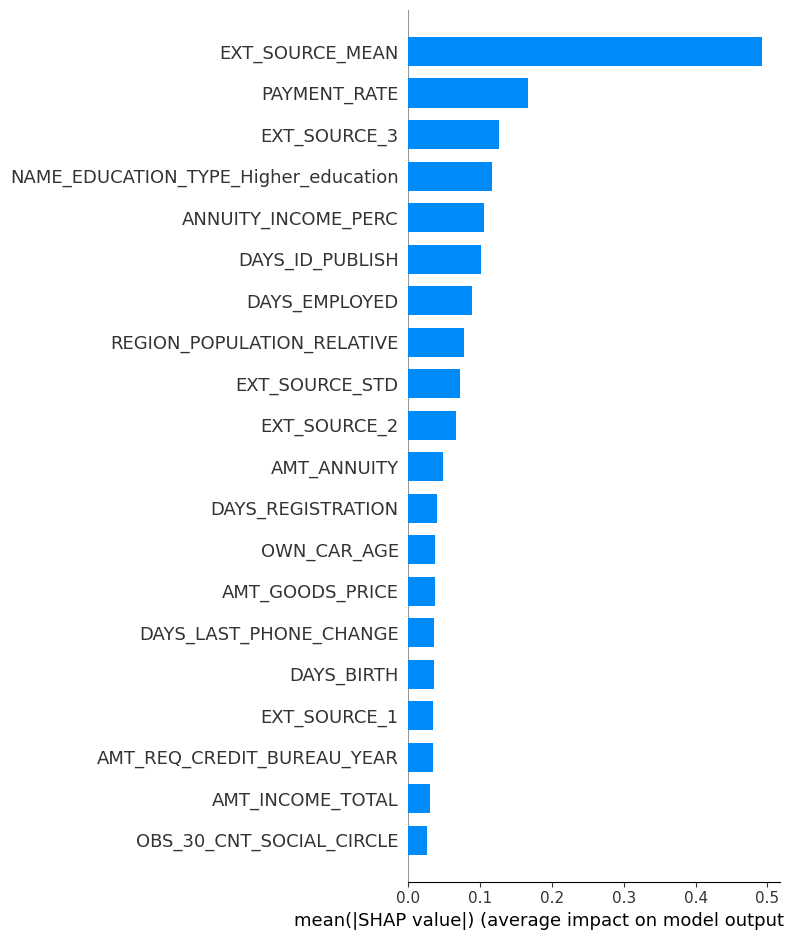

In [45]:
shap.summary_plot( shap_values, X_shap, plot_type="bar")

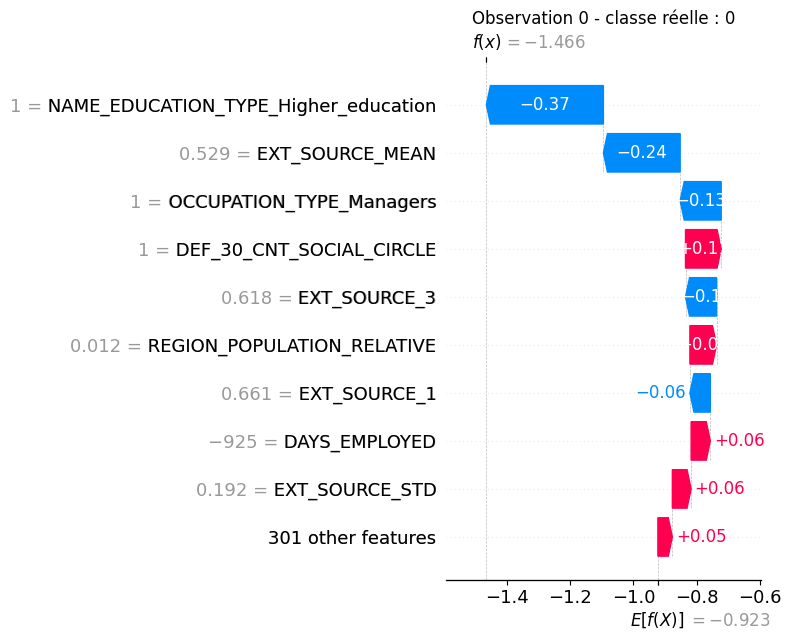

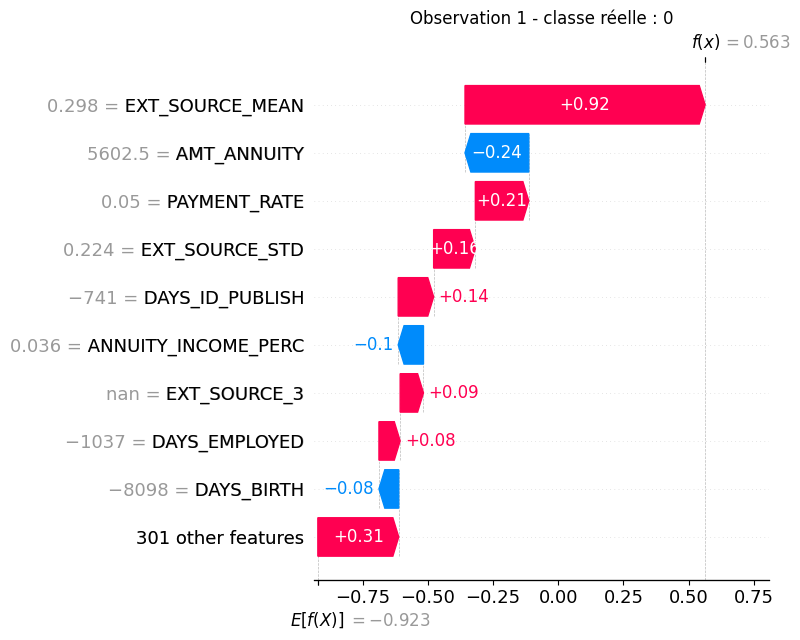

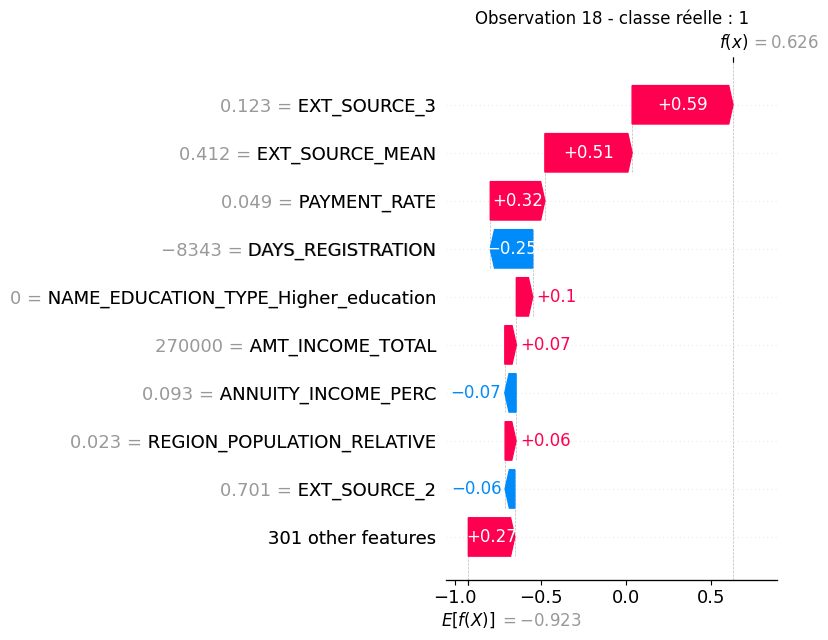

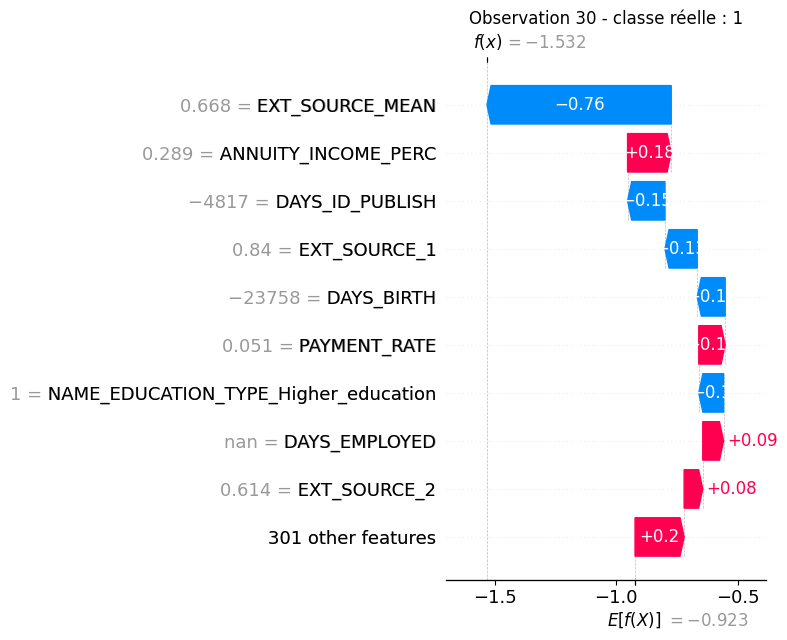

In [49]:
# Indices de 2 observations de chaque classe

# Objet Explanation compatible avec waterfall
shap_explanation = explainer(X_shap)

idx_0 = np.where(y_shap == 0)[0][:2]
idx_1 = np.where(y_shap == 1)[0][:2]

indices = list(idx_0) + list(idx_1)

for i in indices:
    shap.plots.waterfall(
        shap_explanation[i],
        max_display=10,
        show=False
    )

    plt.title(f"Observation {i} - classe réelle : {y_shap.iloc[i]}")
    plt.tight_layout()
    plt.savefig(f"shap_waterfall_obs_{i}.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

### Feature_importance_

In [31]:
# Feature Importances
# ============================================================

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance.head(30)

,feature,importance
128,PAYMENT_RATE,216
129,EXT_SOURCE_MEAN,200
11,DAYS_ID_PUBLISH,170
28,EXT_SOURCE_3,162
9,DAYS_EMPLOYED,160
130,EXT_SOURCE_STD,139
10,DAYS_REGISTRATION,110
7,REGION_POPULATION_RELATIVE,102
45,DAYS_LAST_PHONE_CHANGE,100
27,EXT_SOURCE_2,97


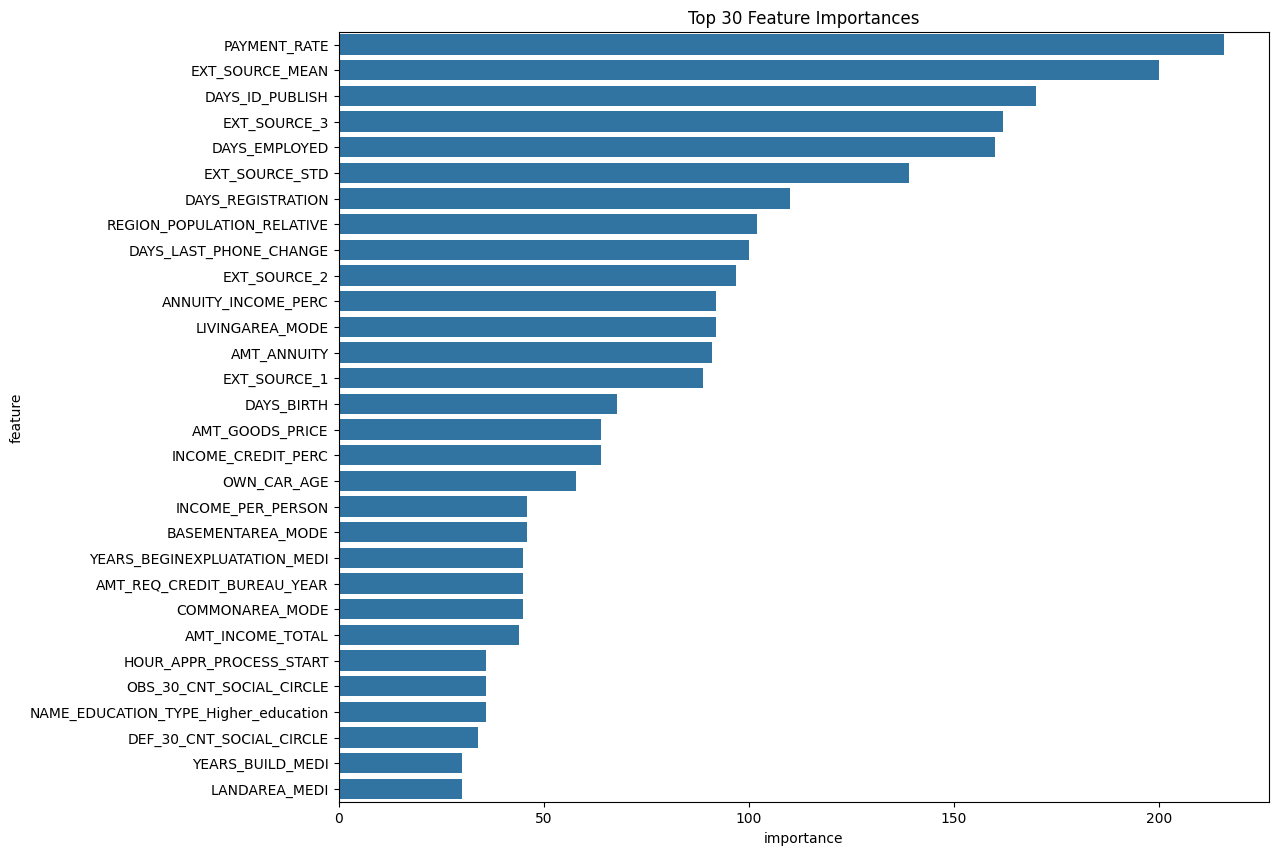

In [32]:
# Top 30 Feature Importances
# ============================================================

plt.figure(figsize=(12, 10))

sns.barplot(
    data=feature_importance.head(30),
    x="importance",
    y="feature"
)

plt.title("Top 30 Feature Importances")
plt.show()

[[7714 1511]
 [ 407  368]]


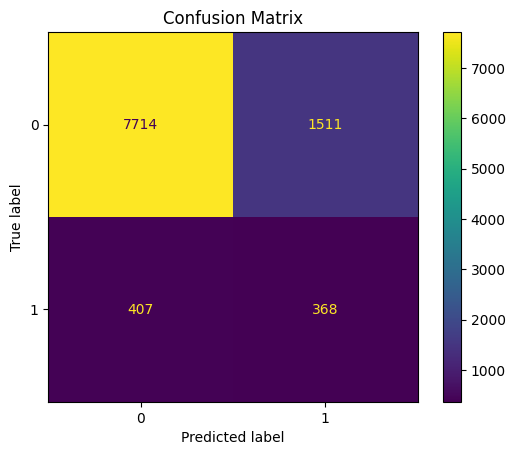

In [ ]:
# confusion matrix
# Conversion probabilités -> classes
y_pred = (oof_preds > 0.5).astype(int) # seuil de 0.5 à réevaluer

cm = confusion_matrix(y, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Confusion Matrix")

plt.show()

In [ ]:
# Exemple simple de regroupement de features pour avoir des features importance correctes
def get_original_feature(col):
    prefixes = [
        "NAME_EDUCATION_TYPE",
        "NAME_INCOME_TYPE",
        "NAME_FAMILY_STATUS",
        "OCCUPATION_TYPE",
        "ORGANIZATION_TYPE",
        "NAME_HOUSING_TYPE",
        "NAME_CONTRACT_TYPE",
        "CODE_GENDER",
        "FLAG_OWN_CAR",
        "FLAG_OWN_REALTY"
    ]

    for prefix in prefixes:
        if col.startswith(prefix + "_"):
            return prefix

    return col

In [ ]:
folds = KFold(n_splits=5, shuffle=True, random_state=42)

oof_preds = np.zeros(len(train_df))
test_preds = np.zeros(len(test_df))
feature_importance = pd.DataFrame()

for fold, (train_idx, valid_idx) in enumerate(folds.split(X, y)):
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_valid, y_valid = X.iloc[valid_idx], y.iloc[valid_idx]

    model = LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.03,
        num_leaves=34,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="auc"
    )

    oof_preds[valid_idx] = model.predict_proba(X_valid)[:, 1]
    test_preds += model.predict_proba(X_test)[:, 1] / folds.n_splits

    fold_importance = pd.DataFrame({
        "feature": features,
        "importance": model.feature_importances_,
        "fold": fold + 1
    })

    feature_importance = pd.concat([feature_importance, fold_importance], axis=0)

    auc = roc_auc_score(y_valid, oof_preds[valid_idx])
    print(f"Fold {fold + 1} AUC: {auc:.5f}")

print("Full AUC:", roc_auc_score(y, oof_preds))